## Домашнее задание: "Детекция объектов на изображении"

ФИО: Амбросий Николай Евгеньевич

## Цель задания:
Научиться самостоятельно решать задачу детекции.
## Описание задания:
В рамках данного домашнего задания предлагается решить задачу детекции мячей и настроить полный пайплайн обучения модели.

Процесс выполнения задания следующий:

0. Выбор модели детекции для обучения:
    1. Выберите модель детекции для выполнения домашнего задания. Любую, кроме RetinaNet. Ее реализацию можно взять из открытых источников. Модель можно брать предобученную ( в этом случае в пункте 4. показать влияние предобучения на финальное качество).
    2. Полезные ссылки: [PyTorch Vision Models](https://pytorch.org/vision/stable/models.html) (блок Object Detection), [SOTA модели детекции](https://paperswithcode.com/sota/object-detection-on-coco), [Возможный пример кода](https://github.com/AlekseySpasenov/dl-course/blob/autumn_2023/lecture8/detection_example/pytorch_detection_workshop.ipynb)
    3. Вы можете использовать RetinaNet, которая была реализована на семинаре, но это приведет к снижению оценки на **–2.5 балла**, так как задания 1.1 и 2.1 уже были выполнены в рамках занятия.

1. Подготовка обучающего набора данных
    0. Для выполнения задания используйте датасет с изображениями мячей, который использовался на семинаре.
    1. Реализуйте корректный класс Dataset и Dataloader для выбранной модели (должен работать форвард вашей модели на том, что выходит из даталоадера) **0.5 балла**.
    2. Добавьте простые аугментации в датасет (аугментации, не затрагивающие изменение ground-truth bounding box) **0.5 балла**.
    3. Внедрите сложные аугментации (аугментации, затрагивающие изменение ground-truth bounding box. Например, аффинные преобразования: сдвиг, поворот и т.д.) **0.5 балла**.

    4. Полезные ссылки: https://pytorch.org/vision/stable/transforms.html , https://albumentations.ai

2. Реализация корректного train-loop и обучение модели:  
    1. Реализуйте эффективный train-loop для вашей модели и проведите обучение **2 балла**.
    2. Выполните несколько запусков обучения с различными параметрами, например: сравните влияние различных аугментаций, оцените влияние того была предобучена модель или нет, сравните результаты при изменении гиперпараметров итд (на ваш выбор) **0.5 балла**.

3. Валидация обученных моделей на тестовой выборке, вычисление метрики mAP
    1. Оцените качество моделей на тестовой части данных и рассчитайте метрику mAP **0.5 балл**
    2. Полезные ссылки: [mean_average_precision](https://github.com/bes-dev/mean_average_precision)

4. Выводы **0.5 балл**:
    1. Проанализируйте результаты обучения, визуально оцените качество работы модели.
    2. Прокомментируйте распространенные ошибки модели и предложите пути для улучшения финального решения.

In [81]:
import json
from ultralytics import YOLO
import torch
from torch.utils.data import Dataset, DataLoader
import os
import cv2
import numpy as np
import torchvision.transforms as T
import matplotlib.pyplot as plt
import albumentations as A
import math
import random

In [ ]:
model = YOLO('yolo11n.pt')
balls_class = [item for item in model.names.items() if 'ball' in item[1].split()][0]
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)

In [82]:
class MyDataset(Dataset):
    def __init__(self, image_dir, annotations, transforms=None):
        super().__init__()
        self.image_dir = image_dir
        with open(annotations) as f:
            self.annotations = json.load(f)
        self.image_keys = list(self.annotations.keys())
        if transforms is not None:
            self.transforms = transforms
        else:
            self.transforms = A.Compose([A.Resize(640, 640), A.ToTensorV2()], bbox_params=A.BboxParams(format="yolo", label_fields=["class_labels"]))

    def __len__(self):
        return len(self.annotations)
    def __getitem__(self, idx):
        image_key = self.image_keys[idx]
        filename = os.path.basename(image_key)
        image_path = os.path.join(self.image_dir, filename)
        image = cv2.imread(image_path)
        if image is None:
            raise FileNotFoundError
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        bboxes = self.annotations[image_key]
        yolo_bboxes = []
        for bbox in bboxes:
            x_min, x_max, y_min, y_max = bbox

            width = x_max - x_min
            height = y_max - y_min
            x_center = x_min + (width / 2)
            y_center = y_min + (height / 2)

            yolo_bboxes.append([x_center, y_center, width, height])

        class_labels = [0] * len(yolo_bboxes)
        transformed = self.transforms(image=image, bboxes=yolo_bboxes, class_labels=class_labels)
        image_tensor = transformed['image']
        yolo_bboxes = transformed['bboxes']
        class_labels = transformed['class_labels']
        labels = []
        for bbox, class_id in zip(yolo_bboxes, class_labels):
            labels.append([class_id, *bbox])
        if not labels:
            return image_tensor, torch.empty((0, 5), dtype=torch.float32)
        labels_tensor = torch.tensor(labels, dtype=torch.float32)
        return image_tensor, labels_tensor

class MyDataLoader:
    def __init__(self, dataset, batch_size=1, shuffle=False):
        self.dataset = dataset
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.n_samples = len(dataset)

    def _collate_batch(self, batch):
        images, labels = zip(*batch)
        images = torch.stack(images, dim=0)
        flattened_labels = []
        for i, label in enumerate(labels):
            if label.shape[0] > 0:
                batch_idx = torch.full((label.shape[0], 1), i)
                label_with_batch_idx = torch.cat((batch_idx, label), dim=1)
                flattened_labels.append(label_with_batch_idx)
        if not flattened_labels:
            return images, torch.empty((0, 6))
        flattened_labels = torch.cat(flattened_labels, dim=0)
        return images, flattened_labels

    def __iter__(self):
        self.indices = list(range(self.n_samples))
        if self.shuffle:
            random.shuffle(self.indices)
        self.batch_counter = 0
        return self

    def __next__(self):
        if self.batch_counter * self.batch_size >= self.n_samples:
            raise StopIteration

        start_idx = self.batch_counter * self.batch_size
        end_idx = min(start_idx + self.batch_size, self.n_samples)
        batch_indices = self.indices[start_idx:end_idx]
        batch_samples = [self.dataset[i] for i in batch_indices]
        self.batch_counter += 1
        return self._collate_batch(batch_samples)

    def __len__(self):
        return math.ceil(self.n_samples / self.batch_size)

def visualize(image_tensor, labels_tensor, class_names=None):
    image_np = image_tensor.permute(1, 2, 0).cpu().numpy()
    if image_np.max() <= 1.0:
        image_np = (image_np * 255).astype(np.uint8)
    else:
        image_np = image_np.astype(np.uint8)

    image_to_draw = image_np.copy()
    height, width, _ = image_to_draw.shape

    for label in labels_tensor:
        class_id, x_center, y_center, box_width, box_height = label

        x_center *= width
        y_center *= height
        box_width *= width
        box_height *= height

        x_min = int(x_center - box_width / 2)
        y_min = int(y_center - box_height / 2)
        x_max = int(x_center + box_width / 2)
        y_max = int(y_center + box_height / 2)

        color = (255, 0, 0)
        thickness = 2
        cv2.rectangle(image_to_draw, (x_min, y_min), (x_max, y_max), color, thickness)

        if class_names and int(class_id) < len(class_names):
            class_name = class_names[int(class_id)]
            cv2.putText(image_to_draw, class_name, (x_min, y_min - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, thickness)

    plt.figure(figsize=(10, 10))
    plt.imshow(image_to_draw)
    plt.show()

In [31]:
BATCH_SIZE = 4
IMAGE_PATH = r"C:\Users\nicol\PycharmProjects\neural_networks\hw6\seminar_objdet_retina_oi5_ball\seminar_objdet_retina_oi5_ball\oi5_ball"
ANNOT_TRAIN_PATH = r"C:\Users\nicol\PycharmProjects\neural_networks\hw6\seminar_objdet_retina_oi5_ball\seminar_objdet_retina_oi5_ball\oi5_ball_filename_to_bbox_train.json"
ANNOT_VAL_PATH = r"C:\Users\nicol\PycharmProjects\neural_networks\hw6\seminar_objdet_retina_oi5_ball\seminar_objdet_retina_oi5_ball\oi5_ball_filename_to_bbox_val.json"


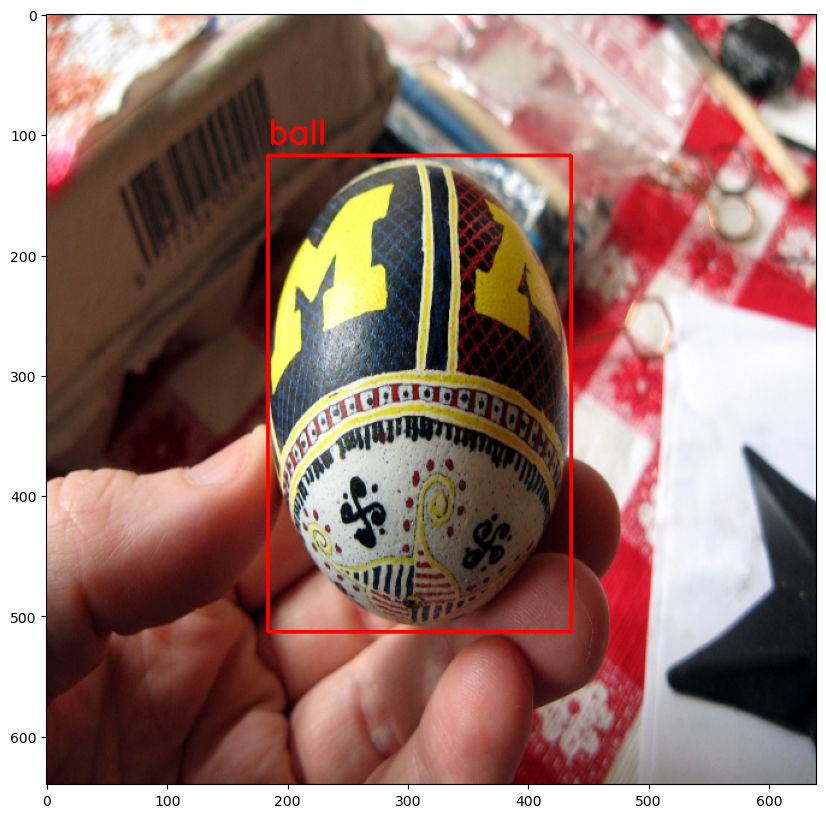

In [83]:
dataset = MyDataset(
    image_dir=IMAGE_PATH,
    annotations=ANNOT_VAL_PATH,
)
data_loader = MyDataLoader(
    dataset=dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
images_batch, labels_batch = next(iter(data_loader))
image_to_visualize = images_batch[0]
labels_for_first_image = labels_batch[labels_batch[:, 0] == 0]
labels_to_visualize = labels_for_first_image[:, 1:]
visualize(image_to_visualize, labels_to_visualize, class_names=['ball'])

simple augmentations

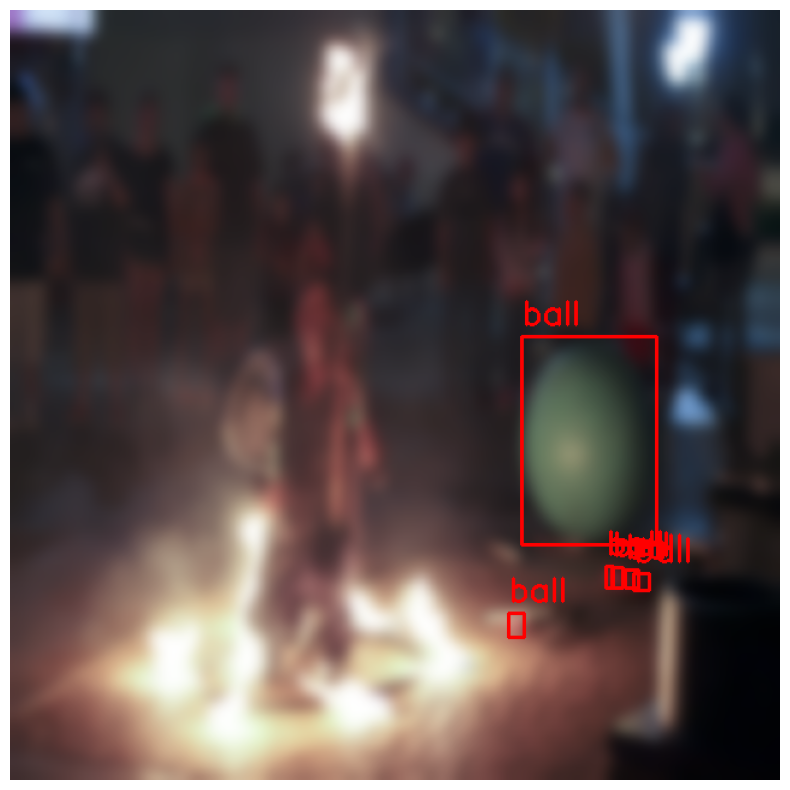

In [56]:
bbox_params = A.BboxParams(format='yolo', label_fields=['class_labels'])
transforms = A.Compose(
    [
        A.Resize(640, 640),
        A.ColorJitter(p=0.5),
        A.GaussianBlur(sigma_limit=10),
        A.ToTensorV2()
    ], bbox_params=bbox_params
)
dataset = MyDataset(
    image_dir=IMAGE_PATH,
    annotations=ANNOT_VAL_PATH,
    transforms=transforms
)
data_loader = MyDataLoader(
    dataset=dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
images_batch, labels_batch = next(iter(data_loader))
image_to_visualize = images_batch[0]
labels_for_first_image = labels_batch[labels_batch[:, 0] == 0]
labels_to_visualize = labels_for_first_image[:, 1:]
visualize(image_to_visualize, labels_to_visualize, class_names=['ball'])

not so simple augmentations

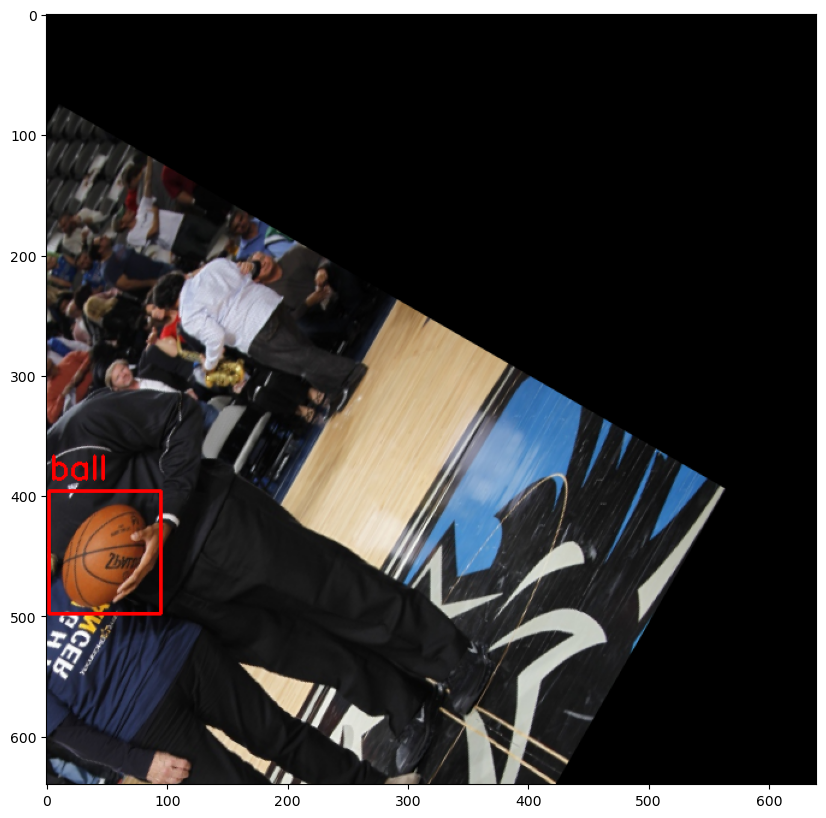

In [87]:
bbox_params = A.BboxParams(format='yolo', label_fields=['class_labels'])
transforms = A.Compose(
    [
        A.Resize(640, 640),
        A.Affine(rotate=(-90, 90), translate_percent=0.3, p=1.0),
        A.RandomSizedBBoxSafeCrop(width=640, height=640, erosion_rate=0.2, p=0.5),
        A.HorizontalFlip(p=0.5),
        A.CoarseDropout(p=0.5),
        A.ToTensorV2(),
    ], bbox_params=bbox_params
)
dataset = MyDataset(
    image_dir=IMAGE_PATH,
    annotations=ANNOT_VAL_PATH,
    transforms=transforms
)
data_loader = MyDataLoader(
    dataset=dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
images_batch, labels_batch = next(iter(data_loader))
image_to_visualize = images_batch[0]
labels_for_first_image = labels_batch[labels_batch[:, 0] == 0]
labels_to_visualize = labels_for_first_image[:, 1:]
visualize(image_to_visualize, labels_to_visualize, class_names=['ball'])